<a href="https://colab.research.google.com/github/crypt0d1v3r/CannyValley/blob/JakeTest/TrainandTestHewgModel_Git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies for pulling datasets
%pip install kagglehub
%pip install datasets
%pip install torch
%pip install torchvision
%pip install numpy
%pip install matplotlib

In [ ]:
import kagglehub
from datasets import load_dataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models # Import models

# We will use a pre-trained ResNet18 instead of a custom CNN
def get_pretrained_model():
    # Load pre-trained ResNet18
    model = models.resnet18(pretrained=True)

    # Freeze all layers (optional, but good for small datasets to prevent overfitting)
    # for param in model.parameters():
    #     param.requires_grad = False

    # Replace the final fully connected layer
    # ResNet18's fc layer has 512 input features
    num_ftrs = model.fc.in_features
    model.fc = torch.nn.Linear(num_ftrs, 2) # 2 output classes
    return model

# Keep the old class for reference, but we won't use it
class CNN(torch.nn.Module):
  def __init__(self):
      super().__init__()
      self.model = torch.nn.Sequential(
          torch.nn.Conv2d(in_channels=3, out_channels=32,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=32, out_channels=64,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=64, out_channels=64,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Flatten(),
          torch.nn.Linear(64 * 28 * 28, 512),
          torch.nn.ReLU(),
          torch.nn.Linear(512, 2)
      )

  def forward(self, x):
      return self.model(x)

In [ ]:
dataset_path = "./datasets"
dataset_source = "Hemg/AI-vs-Real-images"
if dataset_source == "birdy654/cifake-real-and-ai-generated-synthetic-images":
  dataset_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
elif dataset_source == "Hemg/AI-vs-Real-images":
  dataset_path = load_dataset("Hemg/AI-vs-Real-images")
elif dataset_source == "bitmind/AI-vs-Real-Dataset-Images-Proper":
  dataset_path = load_dataset("bitmind/AI-vs-Real-Dataset-Images-Proper")
else:
  raise Exception(f"Dataset Source {dataset_source} Unknown")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/train-00000-of-00006-f19feedd0ed1ea(…):   0%|          | 0.00/91.2M [00:00<?, ?B/s]

data/train-00001-of-00006-95d0f15200cba9(…):   0%|          | 0.00/25.9M [00:00<?, ?B/s]

data/train-00002-of-00006-27c9ab02d7f950(…):   0%|          | 0.00/339M [00:00<?, ?B/s]

data/train-00003-of-00006-d009c6f04a3a8c(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00004-of-00006-a64ab7ba7a79c0(…):   0%|          | 0.00/40.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/127260 [00:00<?, ? examples/s]

Can choose from the following datasets

---



*   birdy654/cifake-real-and-ai-generated-synthetic-images
*   Hemg/AI-vs-Real-images
*   bitmind/AI-vs-Real-Dataset-Images-Proper



In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import transforms, datasets
from PIL import Image
from datasets import DatasetDict, load_dataset
import kagglehub
from google.colab import files

# ResNet expects 224x224 images and specific normalization
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda image: image.convert('RGB')), # Explicitly convert to RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define a custom dataset class for Hugging Face datasets
class HFDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image'] # This is expected to be a PIL Image from Hugging Face datasets
        label = item['label']

        if self.transform:
            image = self.transform(image)
        return image, label

# Conditional data loading based on the type of dataset_path
if isinstance(dataset_path, DatasetDict):
    print("Loading dataset from Hugging Face DatasetDict and creating train/test split.")

    # Use the 'train' split as the full dataset since no 'test' or 'validation' split exists
    full_dataset = HFDataset(dataset_path['train'], transform=data_transforms)

    # Define split ratios (e.g., 80% train, 20% test)
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size

    # Split the dataset
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    if 'label' in dataset_path['train'].features and hasattr(dataset_path['train'].features['label'], 'names'):
        class_names = dataset_path['train'].features['label'].names
    else:
        # Default class names for 'Hemg/AI-vs-Real-images'
        class_names = ["Real", "AI"]
else:
    # This is a string path, assumed for ImageFolder
    print("Loading dataset from local image folders.")
    train_dir = os.path.join(dataset_path, 'train')
    test_dir = os.path.join(dataset_path , 'test')

    train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms)
    class_names = train_dataset.classes

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Classes: {class_names}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- Model Selection Logic ---

use_existing = False
if 'model' in globals():
    print("A model is already in memory.")
    keep = input("Do you want to use the existing model? (y/n): ").lower()
    if keep == 'y':
        use_existing = True
        model = model.to(device)
        print("Using existing model.")

if not use_existing:
    # 2. Check for a saved model file locally
    model_filename = "cnn_model_Hemg_TransferLearn.pth"

    print(f"Checking for local model file: {model_filename}...")
    found_local = os.path.exists(model_filename)

    choice = 'n'
    if found_local:
        choice = input(f"Found saved model '{model_filename}'. Load it? (y/n/upload): ").lower()
    else:
        choice = input("No local model found. Upload a model? (upload/new): ").lower()

    if choice == 'y' and found_local:
        print(f"Loading weights from {model_filename}...")
        model = get_pretrained_model().to(device)
        model.load_state_dict(torch.load(model_filename, map_location=device))
        model.eval()
    elif 'upload' in choice:
         # 3. Prompt for upload
         print("Please upload your .pth file:")
         uploaded = files.upload()
         for filename in uploaded.keys():
             print(f"Loading uploaded model: {filename}...")
             model = get_pretrained_model().to(device)
             model.load_state_dict(torch.load(filename, map_location=device))
             model.eval()
             break # Load only the first one
    else:
         # 4. Fallback: Initialize new pre-trained model
         print("Initializing new pre-trained ResNet18 model (fresh weights).")
         model = get_pretrained_model().to(device)

Loading dataset from Hugging Face DatasetDict and creating train/test split.
Classes: ['Fake', 'Real']
Using device: cuda
A model is already in memory.
Do you want to use the existing model? (y/n): n
Checking for local model file: cnn_model_Hemg_TransferLearn.pth...
Found saved model 'cnn_model_Hemg_TransferLearn.pth'. Load it? (y/n/upload): y
Loading weights from cnn_model_Hemg_TransferLearn.pth...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
print(dataset_path)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 127260
    })
})


Starting training with ResNet18...
Epoch 1/10: 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Training loss = 0.2919
Epoch 2/10: Training loss = 0.2393
Epoch 3/10: Training loss = 0.2279
Epoch 4/10: Training loss = 0.2267
Epoch 5/10: Training loss = 0.1999
Epoch 6/10: Training loss = 0.1885
Epoch 7/10: Training loss = 0.1823
Epoch 8/10: Training loss = 0.1803
Epoch 9/10: Training loss = 0.1736
Epoch 10/10: Training loss = 0.1713


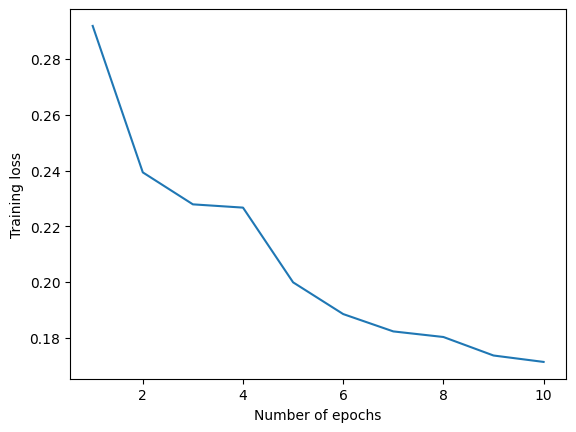

Test set accuracy = 94.31 %


In [ ]:
from torch.optim.lr_scheduler import StepLR

num_epochs = 10 # Reduced to 10 as pre-trained models converge faster
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()

# Ensure model is on the correct device
model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Decay LR by a factor of 0.1 every 4 epochs
scheduler = StepLR(optimizer, step_size=4, gamma=0.1)

train_loss_list = []
print("Starting training with ResNet18...")

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
    train_loss = 0
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Step the scheduler
    scheduler.step()

    avg_loss = train_loss / len(train_loader)
    train_loss_list.append(avg_loss)
    print(f"Training loss = {avg_loss:.4f}")

plt.plot(range(1, num_epochs + 1), train_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")
plt.show()



Test set accuracy = 94.47 %


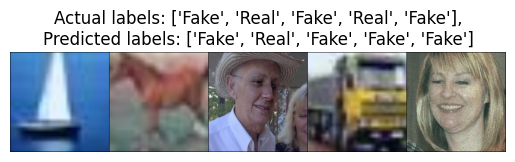

In [ ]:
import torchvision # Added import for torchvision

# Evaluation
test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset):.2f} %")

num_images = 5
y_true_name = [class_names[y_true[idx]] for idx in range(num_images)]
y_pred_name = [class_names[y_pred[idx]] for idx in range(num_images)]
title = f"Actual labels: {y_true_name},\nPredicted labels: {y_pred_name}"

plt.imshow(np.transpose(torchvision.utils.make_grid(images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")
plt.show()

In [ ]:
# Save the trained model weights
torch.save(model.state_dict(), "cnn_model_Hemg.pth")
print("Model saved to cnn_model.pth")

# To load later:
# model = CNN().to(device)
# model.load_state_dict(torch.load("cnn_model.pth"))
# model.eval()

Model saved to cnn_model.pth


In [ ]:
from google.colab import files
files.download('cnn_model_Hemg.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
from PIL import Image

# Upload an image file
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  image_path = fn

# If you prefer to use an existing image on disk, you can set image_path directly:
# image_path = "path/to/your/image.jpg"

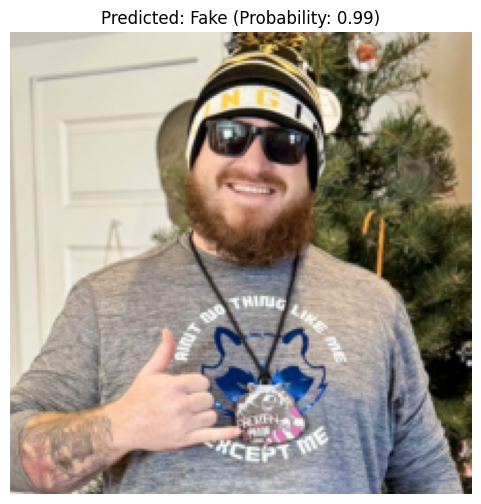

Class Probabilities:
  Fake: 0.9949
  Real: 0.0051
The model predicts this image is: Fake with probability 0.99


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms

# Function to classify a single image
def classify_image(image_path, model, transforms, class_names, device):
    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Apply transformations
    input_tensor = transforms(image)

    # Add batch dimension and move to device
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.nn.functional.softmax(output, dim=1)[0] # Get probabilities for the single image
        _, predicted_class_idx = torch.max(probabilities, 0) # Use 0 for a single tensor

    predicted_class_name = class_names[predicted_class_idx.item()]
    predicted_probability = probabilities[predicted_class_idx.item()].item()

    # Display the image and prediction
    plt.figure(figsize=(6, 6))
    # Denormalize the tensor for display
    display_image_tensor = input_tensor.clone().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    display_image_tensor = display_image_tensor * std + mean
    # Ensure values are in [0, 1] range for imshow and convert to numpy array
    display_image_tensor = torch.clamp(display_image_tensor, 0, 1)
    plt.imshow(display_image_tensor.numpy().transpose((1, 2, 0)))
    plt.title(f"Predicted: {predicted_class_name} (Probability: {predicted_probability:.2f})")
    plt.axis('off')
    plt.show()

    # Print all class probabilities
    print("Class Probabilities:")
    for i, prob in enumerate(probabilities):
        print(f"  {class_names[i]}: {prob.item():.4f}")

    return predicted_class_name, predicted_probability

# We removed the redundant model definition and loading here.
# The code now relies on the 'model' object loaded in previous cells.

# Define data_transforms specific for this visualization
# Added an initial Resize to 64x64 to simulate lower resolution, then resize up
data_transforms_viz = transforms.Compose([
    transforms.Resize(256),  # Downsample to simulate low resolution (even lower)
    transforms.Resize(256), # Then upscale for model input size, making it blurry
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Assuming class_names is ['FAKE', 'REAL'] from previous execution
# If not, it would need to be re-defined here as well for robustness
if 'class_names' not in locals():
    class_names = ['FAKE', 'REAL'] # Explicitly define for robustness

# Classify the uploaded image
# The image_path variable is set by the previous cell (0943dcbc) after file upload
if 'image_path' in locals():
    predicted_class, probability = classify_image(image_path, model, data_transforms_viz, class_names, device)
    print(f"The model predicts this image is: {predicted_class} with probability {probability:.2f}")
else:
    print("Error: image_path is not defined. Please run the cell above to upload an image.")